# 12. 고윳값 분해

## 행렬이 방향을 바꾸지 않는 특별한 벡터

- **배울 것**: 고윳값·고유벡터, 대각화, 대칭행렬, 일반화 고유분해와 백색화.

$$
A\mathbf v=\lambda\mathbf v,\quad\mathbf v\ne0,\qquad
\det(A-\lambda I)=0
$$

- 고유벡터 방향은 변환 후 같은 직선 위에 남습니다. 고윳값은 그 방향의 배율입니다. 음수이면 반대 방향, 0이면 영벡터가 됩니다.
- $A=\begin{bmatrix}2&1\\1&2\end{bmatrix}$는 $(1,1)$ 방향을 3배, $(1,-1)$ 방향을 1배로 만듭니다.
- NumPy가 반환하는 고유벡터는 **열**에 있습니다. `V[:,i]`가 `eigenvalues[i]`에 대응합니다.

## 대각화는 좋은 좌표계로 옮겨서 계산하는 일

$$
AV=V\Lambda,\qquad A=V\Lambda V^{-1}
$$

- 서로 독립인 고유벡터를 충분히 얻어 V가 가역일 때 대각화가 가능합니다. 모든 정사각행렬이 대각화되는 것은 아닙니다.
- 실수 대칭행렬은 직교정규 고유기저를 택할 수 있어 $A=Q\Lambda Q^T$입니다. 대칭 문제에는 `np.linalg.eigh`가 적합합니다.
- 벡터의 부호는 유일하지 않습니다. 고윳값을 정렬하면 고유벡터 열도 같은 순서로 옮겨야 합니다.
- 이차형식 $x^TAx$의 양수 여부를 고윳값으로 판단하는 기준은 대칭행렬에 적용합니다. 일반 A에서는 대칭부분 $(A+A^T)/2$가 이차형식을 결정합니다.

## 공분산, 백색화, 일반화 고유분해

$$
C=V\Lambda V^T,\quad Z=X_cV\Lambda^{-1/2},\qquad
A\mathbf v=\lambda B\mathbf v
$$

- 공분산의 고윳값은 각 주방향의 분산입니다. 회전한 뒤 분산의 제곱근으로 나누면 공분산이 항등행렬이 되는 백색화를 얻습니다.
- 0에 가까운 고윳값을 역수로 바꾸면 잡음이 커집니다. 제거하거나 정규화해야 합니다.
- A가 대칭, B가 대칭 양의 정부호일 때 `scipy.linalg.eigh(A,B)`를 사용할 수 있습니다. 반환 벡터는 $V^TBV=I$로 정규화되며 보통 $V^TV=I$는 아닙니다.
- **주의**: 이 장의 생성 데이터는 유한 표본이므로 표본 상관이 목표 상관과 완전히 일치하지는 않습니다.

## 읽기 안내

- 이 글은 제공된 Python 예제를 바탕으로 새로 작성한 해설입니다. 연습문제의 질문은 코드에서 확인되는 학습 목표를 재구성했으며 책의 문제 원문을 옮긴 것이 아닙니다.
- 코드·실행 결과는 아래 순서로 연결됩니다. 앞 셀의 변수를 쓰므로 노트북은 처음부터 실행하세요.
- 난수 시드는 장마다 고정했습니다. 실행 시간과 마지막 소수 자릿수는 환경에 따라 달라질 수 있습니다.
- `1e-14` 같은 작은 잔차는 부동소수점 오차일 수 있습니다. 수학적 0과 컴퓨터의 정확한 0을 구분하세요.

## 실행 환경


In [1]:
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT / 'blog_linear_algebra'
DATA = ROOT / 'data'
ASSET = ROOT / 'assets' / 'ch12'
ASSET.mkdir(parents=True, exist_ok=True)
np.random.seed(20260937)
np.set_printoptions(precision=6, suppress=True, threshold=120)
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 140, 'font.size': 12})
print('재현용 난수 시드:', 20260937)

재현용 난수 시드: 20260937


### 코드 12-01

- 원본: `original_py/LA4DS_ch12.py` 1–7행.
- **보완**: Markdown 호환을 위해 그림 출력을 PNG로 지정했습니다.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# NOTE: these lines define global figure properties used for publication.
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('png') # display figures in vector format
plt.rcParams.update({'font.size':14}) # set global font size

### 고유벡터의 기하학

### 코드 12-02

- 원본: `original_py/LA4DS_ch12.py` 11–57행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

[-0.618034+0.j  1.618034+0.j]


D:\Linear_Algebra\.venv\Lib\site-packages\matplotlib\cbook.py:1811: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
D:\Linear_Algebra\.venv\Lib\site-packages\matplotlib\cbook.py:1408: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asanyarray(x, float)


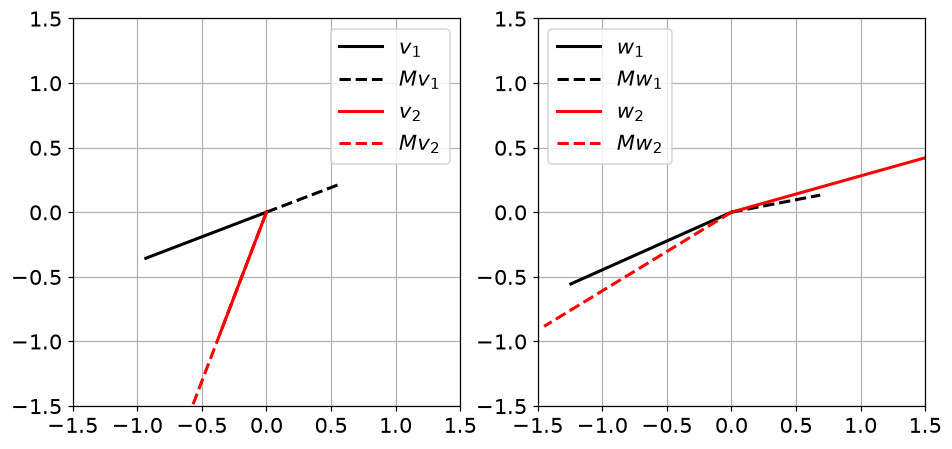

In [3]:
# in 2D of course, for visualization

# the matrix
M = np.array([ [-1,1],
               [-1,2] ])

# its eigenvalues and eigenvectors
eigenvalues,eigenvectors = np.linalg.eig(M)
print(eigenvalues)

# some random vectors
notEigenvectors = np.random.randn(2,2)

# multipy to create new vectors
Mv = M @ eigenvectors
Mw = M @ notEigenvectors



## and now plot
_,axs = plt.subplots(1,2,figsize=(10,6))

# the two eigenvectors
axs[0].plot([0,eigenvectors[0,0]],[0,eigenvectors[1,0]],'k',linewidth=2,label='$v_1$')
axs[0].plot([0,Mv[0,0]],[0,Mv[1,0]],'k--',linewidth=2,label='$Mv_1$')

axs[0].plot([0,eigenvectors[0,1]],[0,eigenvectors[1,1]],'r',linewidth=2,label='$v_2$')
axs[0].plot([0,Mv[0,1]],[0,Mv[1,1]],'r--',linewidth=2,label='$Mv_2$')

# the two non-eigenvectors
axs[1].plot([0,notEigenvectors[0,0]],[0,notEigenvectors[1,0]],'k',linewidth=2,label='$w_1$')
axs[1].plot([0,Mw[0,0]],[0,Mw[1,0]],'k--',linewidth=2,label='$Mw_1$')

axs[1].plot([0,notEigenvectors[0,1]],[0,notEigenvectors[1,1]],'r',linewidth=2,label='$w_2$')
axs[1].plot([0,Mw[0,1]],[0,Mw[1,1]],'r--',linewidth=2,label='$Mw_2$')


# adjust the graphs a bit
for i in range(2):
  axs[i].axis('square')
  axs[i].set_xlim([-1.5,1.5])
  axs[i].set_ylim([-1.5,1.5])
  axs[i].grid()
  axs[i].legend()

plt.savefig(ASSET / 'Figure_12_01.png',dpi=140)
plt.show()

### 고윳값 계산

### 코드 12-03

- 원본: `original_py/LA4DS_ch12.py` 61–68행.

In [4]:
matrix = np.array([
             [1,2],
             [3,4]
             ])

# get the eigenvalues
evals = np.linalg.eig(matrix)[0]
evals

Out[4]: array([-0.372281+0.j,  5.372281+0.j])


### 코드 12-04

- 원본: `original_py/LA4DS_ch12.py` 70–74행.

In [5]:
# Finding eigenvectors

evals,evecs = np.linalg.eig(matrix)
print(evals), print(' ')
print(evecs)

[-0.372281+0.j  5.372281+0.j]
 
[[-0.824565+0.j -0.415974+0.j]
 [ 0.565767+0.j -0.909377+0.j]]


### 고유벡터 계산

### 코드 12-05

- 원본: `original_py/LA4DS_ch12.py` 78–85행.

In [6]:
# same matrix as above
evals,evecs = np.linalg.eig(matrix)

print('List of eigenvalues:')
print(evals)

print(f'\nMatrix of eigenvectors (in the columns!):')
print(evecs)

List of eigenvalues:
[-0.372281+0.j  5.372281+0.j]

Matrix of eigenvectors (in the columns!):
[[-0.824565+0.j -0.415974+0.j]
 [ 0.565767+0.j -0.909377+0.j]]


### 대각화

### 코드 12-06

- 원본: `original_py/LA4DS_ch12.py` 89–91행.

In [7]:
# using variables created above
D = np.diag(evals)
D

Out[7]: 
array([[-0.372281+0.j,  0.      +0.j],
       [ 0.      +0.j,  5.372281+0.j]])


### 코드 12-07

- 원본: `original_py/LA4DS_ch12.py` 93–103행.

In [8]:
# confirm the matrix eigenvalue equation:
LHS = matrix @ evecs
RHS = evecs @ D


# print out the two sides of the equation
print('Left-hand side:')
print(LHS)

print(f'\nRight-hand side:')
print(RHS)

Left-hand side:
[[ 0.30697 +0.j -2.234727+0.j]
 [-0.210625+0.j -4.885428+0.j]]

Right-hand side:
[[ 0.30697 +0.j -2.234727+0.j]
 [-0.210625+0.j -4.885428+0.j]]


### 대칭행렬의 고유분해

### 코드 12-08

- 원본: `original_py/LA4DS_ch12.py` 107–119행.

In [9]:
# just some random matrix
A = np.random.randint(-3,4,(3,3))

# and make it symmetric
A = A.T@A

# its eigendecomposition
L,V = np.linalg.eig(A)

# all pairwise dot products
print( np.dot(V[:,0],V[:,1]) )
print( np.dot(V[:,0],V[:,2]) )
print( np.dot(V[:,1],V[:,2]) )

(-3.3306690738754696e-16+0j)
(-1.6653345369377348e-16+0j)
(1.6653345369377348e-16+0j)


### 코드 12-09

- 원본: `original_py/LA4DS_ch12.py` 121–122행.

In [10]:
# show that V'V=I
np.round( V.T@V ,10) # rounded for visibility (precision errors...)

Out[10]: 
array([[ 1.+0.j, -0.+0.j, -0.+0.j],
       [-0.+0.j,  1.+0.j,  0.+0.j],
       [-0.+0.j,  0.+0.j,  1.+0.j]])


### 코드 12-10

- 원본: `original_py/LA4DS_ch12.py` 124–137행.

In [11]:
# real-valued matrix with complex-valued eigenvalues

# a matrix
A = np.array([[-3, -3, 0],
              [ 3, -2, 3],
              [ 0,  1, 2]])


# btw, random matrices often have complex eigenvalues (though this is not guaranteed):
#A = np.random.randint(-3,4,(3,3))

# its eigendecomposition
L,V = np.linalg.eig(A)
L.reshape(-1,1) # print as column vector

Out[11]: 
array([[-2.744739+2.851726j],
       [-2.744739-2.851726j],
       [ 2.489478+0.j      ]])


### 코드 12-11

- 원본: `original_py/LA4DS_ch12.py` 139–153행.

In [12]:
# repeat for symmetric matrices

# a matrix
A = np.array([[-3, -3, 0],
              [-3, -2, 1],
              [ 0,  1, 2]])


# you can also demonstrate this with random symmetric matrices
#A = np.random.randint(-3,4,(3,3))
#A = A.T@A

# its eigendecomposition
L,V = np.linalg.eig(A)
L.reshape(-1,1) # print as column vector

Out[12]: 
array([[-5.597071+0.j],
       [ 0.226062+0.j],
       [ 2.37101 +0.j]])


### 특이행렬의 고유분해

### 코드 12-12

- 원본: `original_py/LA4DS_ch12.py` 157–174행.

In [13]:
# a singular matrix
A = np.array([[1,4,7],
              [2,5,8],
              [3,6,9]])

# its eigendecomposition
L,V = np.linalg.eig(A)


# print its rank...
print( f'Rank = {np.linalg.matrix_rank(A)}\n' )

# ... and its eigendecomposition
print('Eigenvalues: ')
print(L.round(2)), print(' ')

print('Eigenvectors:')
print(V.round(2))

Rank = 2

Eigenvalues: 
[16.12+0.j -1.12+0.j -0.  +0.j]
 
Eigenvectors:
[[-0.46+0.j -0.88+0.j  0.41+0.j]
 [-0.57+0.j -0.24+0.j -0.82+0.j]
 [-0.68+0.j  0.4 +0.j  0.41+0.j]]


### 코드 12-13

- 원본: `original_py/LA4DS_ch12.py` 176–181행.

In [14]:
# FYI, random singular matrix
M = np.random.randn(5,3) @ np.random.randn(3,5)
M = M.T@M # make it symmetric for real-valued eigenvalues

# print its eigenvalues (rounded and columnized for clarity)
np.linalg.eig(M)[0].reshape(-1,1).round(3)

Out[14]: 
array([[116.513+0.j],
       [ 30.474+0.j],
       [  6.084+0.j],
       [  0.   +0.j],
       [ -0.   +0.j]])


### 이차형식

### 코드 12-14

- 원본: `original_py/LA4DS_ch12.py` 185–193행.

In [15]:
# a matrix with only positive quad.form values
A = np.array([ [2,4],[0,3] ])
print('Eigenvalues: ')
print(np.linalg.eig(A)[0])

# print the quadratic form for some random vectors
x,y = np.random.randn(2)
print(f'\nSome random quadratic form result:')
A[0,0]*x**2 + (A[1,0]+A[0,1])*x*y + A[1,1]*y**2

Eigenvalues: 
[2.+0.j 3.+0.j]

Some random quadratic form result:
Out[15]: np.float64(1.15162341436648)


### 코드 12-15

- 원본: `original_py/LA4DS_ch12.py` 195–203행.

In [16]:
# a matrix with both positive and negative quad.form values
A = np.array([ [-9,4],[3,9] ])
print('Eigenvalues: ')
print(np.linalg.eig(A)[0])

# print the quadratic form for some random vectors
x,y = np.random.randn(2)
print(f'\nSome random quadratic form result:')
A[0,0]*x**2 + (A[1,0]+A[0,1])*x*y + A[1,1]*y**2

Eigenvalues: 
[-9.643651+0.j  9.643651+0.j]

Some random quadratic form result:
Out[16]: np.float64(-0.19423676157630143)


### 일반화 고유분해

### 코드 12-16

- 원본: `original_py/LA4DS_ch12.py` 207–221행.

In [17]:
n = 4

# create symmetric matrices
A = np.random.randn(n,n)
A = A.T@A

# impose a correlation between the two matrices (this improves numerical stability of the simultaneousl diagonalization)
B = np.random.randn(n,n)
B = B.T@B + A/10


# using scipy
from scipy.linalg import eigh
evals,evecs = eigh(A,B)
evals

Out[17]: array([0.002364, 0.90268 , 1.254818, 3.838759])


## 연습문제 1 · 역행렬의 고윳값

- **목표**: 역변환의 배율이 원래 배율의 역수인지 확인합니다.
- **풀이 순서**: 양의 정부호 A와 inv(A)의 고윳값을 구해 역수를 취한 뒤 정렬해 비교합니다.
- **결과 해석**: $\lambda\ne0$이면 inv(A)의 고윳값은 $1/\lambda$입니다. 역수를 취하면 크기 순서가 뒤집히므로 단순 위치 비교는 피합니다.

### 코드 12-17

- 원본: `original_py/LA4DS_ch12.py` 225–246행.

In [18]:
# create the matrix
A = np.random.randn(5,5)
A = A.T@A

# compute its inverse
Ai = np.linalg.inv(A)

# eigenvalues of A and Ai
eigvals_A  = np.linalg.eig(A)[0]
eigvals_Ai = np.linalg.eig(Ai)[0]

# compare them (hint: sorting helps!)
print('Eigenvalues of A:')
print(np.sort(eigvals_A))

print(' ')
print('Eigenvalues of inv(A):')
print(np.sort(eigvals_Ai))

print(' ')
print('Reciprocal of evals of inv(A):')
print(np.sort(1/eigvals_Ai))

Eigenvalues of A:
[0.139621+0.j 1.951156+0.j 3.587426+0.j 7.710164+0.j 9.808008+0.j]
 
Eigenvalues of inv(A):
[0.101957+0.j 0.129699+0.j 0.278751+0.j 0.512517+0.j 7.162257+0.j]
 
Reciprocal of evals of inv(A):
[0.139621+0.j 1.951156+0.j 3.587426+0.j 7.710164+0.j 9.808008+0.j]


## 연습문제 2 · 고유벡터를 행으로 잘못 읽기

- **목표**: NumPy 반환 배열에서 열과 행의 의미를 구분합니다.
- **풀이 순서**: 앞의 올바른 그림과 달리 고유벡터 행을 좌표로 그리는 원본 실험을 관찰합니다.
- **결과 해석**: 일반적으로 변환 전후가 같은 직선에 놓이지 않습니다. 이 셀은 오류를 드러내는 비교 실험으로 유지했습니다. 올바른 벡터는 V[:,i]입니다.

### 코드 12-18

- 원본: `original_py/LA4DS_ch12.py` 250–292행.

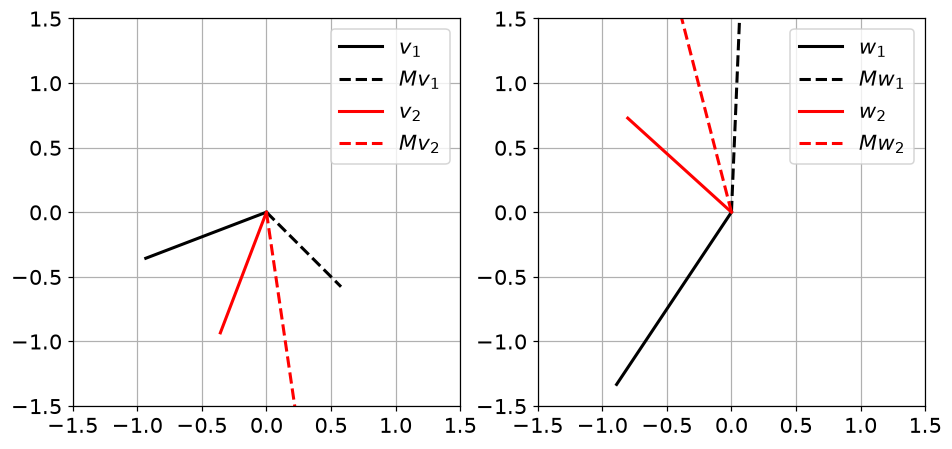

In [19]:
# the matrix
M = np.array([ [-1,1],
               [-1,2] ])

# its eigenvalues and eigenvectors
eigenvalues,eigenvectors = np.linalg.eig(M)

# some random vectors
notEigenvectors = np.random.randn(2,2)

# multipy to create new vectors
Mv = M @ eigenvectors
Mw = M @ notEigenvectors



## and now plot
_,axs = plt.subplots(1,2,figsize=(10,6))

# the two eigenvectors
axs[0].plot([0,eigenvectors[0,0]],[0,eigenvectors[0,1]],'k',linewidth=2,label='$v_1$')
axs[0].plot([0,Mv[0,0]],[0,Mv[0,1]],'k--',linewidth=2,label='$Mv_1$')

axs[0].plot([0,eigenvectors[1,0]],[0,eigenvectors[1,1]],'r',linewidth=2,label='$v_2$')
axs[0].plot([0,Mv[1,0]],[0,Mv[1,1]],'r--',linewidth=2,label='$Mv_2$')

# the two non-eigenvectors
axs[1].plot([0,notEigenvectors[0,0]],[0,notEigenvectors[0,1]],'k',linewidth=2,label='$w_1$')
axs[1].plot([0,Mw[0,0]],[0,Mw[0,1]],'k--',linewidth=2,label='$Mw_1$')

axs[1].plot([0,notEigenvectors[1,0]],[0,notEigenvectors[1,1]],'r',linewidth=2,label='$w_2$')
axs[1].plot([0,Mw[1,0]],[0,Mw[1,1]],'r--',linewidth=2,label='$Mw_2$')


# adjust the graphs a bit
for i in range(2):
  axs[i].axis('square')
  axs[i].set_xlim([-1.5,1.5])
  axs[i].set_ylim([-1.5,1.5])
  axs[i].grid()
  axs[i].legend()

plt.show()

## 연습문제 3 · 고윳값 대응 관계 바꾸기

- **목표**: 고윳값·고유벡터의 짝이 재구성에 중요함을 확인합니다.
- **풀이 순서**: 원래 짝으로 복원한 뒤 고윳값 전체 또는 큰 두 개·작은 두 개만 바꿔 오차를 비교합니다.
- **결과 해석**: 짝을 유지한 복원만 0 근처 오차입니다. 두 고윳값만 맞바꾸면 오차는 $\sqrt2|\lambda_a-\lambda_b|$입니다. 원본의 전체 정렬 혼입을 수정했습니다.

### 코드 12-19

- 원본: `original_py/LA4DS_ch12.py` 296–317행.

In [20]:
# instructions don't specify matrix size; I'll use n=5
N = 5

# to store the reconstruction accuracies
reconAcc = np.zeros(4)


# Create a symmetric random-integers matrix
A = np.random.randn(N,N)
A = np.round( A.T@A )

# diagonalize the matrix
d,V  = np.linalg.eig(A)
D    = np.diag(d)

# demonstrate reconstruction accuracy
# remember that inv(V)=V.T!
Arecon = V @ D @ V.T
print(np.round( A-Arecon ,4))

reconAcc[0] = np.sqrt(np.sum( (A-Arecon)**2 ))
print(f'\nFrobenius distance: {reconAcc[0]}')

[[-0.+0.j -0.+0.j -0.+0.j  0.+0.j -0.+0.j]
 [-0.+0.j  0.+0.j  0.+0.j  0.+0.j  0.+0.j]
 [-0.+0.j  0.+0.j -0.+0.j  0.+0.j -0.+0.j]
 [ 0.+0.j  0.+0.j  0.+0.j -0.+0.j  0.+0.j]
 [-0.+0.j  0.+0.j -0.+0.j  0.+0.j -0.+0.j]]

Frobenius distance: 2.924890743701701e-14


<ipython-input-20-e107b56b348e>:21: ComplexWarning: Casting complex values to real discards the imaginary part
  reconAcc[0] = np.sqrt(np.sum( (A-Arecon)**2 ))


### 코드 12-20

- 원본: `original_py/LA4DS_ch12.py` 319–327행.

In [21]:
# create D-tilde
Dtild = np.diag( d[np.random.permutation(N)] )

# test reconstruction accuracy
Arecon = V @ Dtild @ V.T
print(np.round( A-Arecon ,4))

reconAcc[1] = np.sqrt(np.sum( (A-Arecon)**2 ))
print(f'\nFrobenius distance: {reconAcc[1]}')

[[-14.855 +0.j   7.3512+0.j   0.6909+0.j  -0.0896+0.j   4.8492+0.j]
 [  7.3512+0.j  -0.4141+0.j  -0.4216+0.j   0.8207+0.j   1.2105+0.j]
 [  0.6909+0.j  -0.4216+0.j   1.9226+0.j  -0.8713+0.j   4.5856+0.j]
 [ -0.0896+0.j   0.8207+0.j  -0.8713+0.j  -0.0239+0.j  -2.1516+0.j]
 [  4.8492+0.j   1.2105+0.j   4.5856+0.j  -2.1516+0.j  13.3704+0.j]]

Frobenius distance: 24.8365275729764


<ipython-input-21-ba995d6141c1>:8: ComplexWarning: Casting complex values to real discards the imaginary part
  reconAcc[1] = np.sqrt(np.sum( (A-Arecon)**2 ))


### 코드 12-21

- 원본: `original_py/LA4DS_ch12.py` 329–341행.
- **보완**: 정렬 순서를 전체에 적용하지 않고 실제 두 고윳값의 위치만 교환합니다.

In [22]:
### swap only the two largest eigenvalues
evals_sort_idx = np.argsort(d) # note: default is to sort 
i = np.arange(N)
a,b = evals_sort_idx[-2:]
i[a],i[b] = i[b],i[a]

# create D-tilde
Dtild = np.diag( d[i] )

# test reconstruction accuracy
Arecon = V @ Dtild @ V.T
print(np.round( A-Arecon ,4))

reconAcc[2] = np.sqrt(np.sum( (A-Arecon)**2 ))
print(f'\nFrobenius distance: {reconAcc[2]}')

[[ 0.3815+0.j  0.1417+0.j  0.0697+0.j -0.6239+0.j  2.3696+0.j]
 [ 0.1417+0.j -0.4036+0.j -1.8978+0.j -1.3957+0.j  2.3365+0.j]
 [ 0.0697+0.j -1.8978+0.j -8.0989+0.j -5.0223+0.j  6.5743+0.j]
 [-0.6239+0.j -1.3957+0.j -5.0223+0.j -1.9495+0.j -0.1598+0.j]
 [ 2.3696+0.j  2.3365+0.j  6.5743+0.j -0.1598+0.j 10.0705+0.j]]

Frobenius distance: 18.49688993126428


<ipython-input-22-f11cb0bc747f>:14: ComplexWarning: Casting complex values to real discards the imaginary part
  reconAcc[2] = np.sqrt(np.sum( (A-Arecon)**2 ))


### 코드 12-22

- 원본: `original_py/LA4DS_ch12.py` 343–355행.
- **보완**: 가장 작은 두 고윳값만 교환하도록 수정했습니다.

In [23]:
### swap only the two smallest eigenvalues
evals_sort_idx = np.argsort(d) # note: default is to sort 
i = np.arange(N)
a,b = evals_sort_idx[:2]
i[a],i[b] = i[b],i[a]

# create D-tilde
Dtild = np.diag( d[i] )

# test reconstruction accuracy
Arecon = V @ Dtild @ V.T
print(np.round( A-Arecon ,4))

reconAcc[3] = np.sqrt(np.sum( (A-Arecon)**2 ))
print(f'\nFrobenius distance: {reconAcc[3]}')

[[ 0.7219+0.j -0.3367+0.j -0.0318+0.j  0.0976+0.j -0.0695+0.j]
 [-0.3367+0.j -0.0155+0.j -0.0684+0.j  0.2842+0.j  0.132 +0.j]
 [-0.0318+0.j -0.0684+0.j -0.0387+0.j  0.1547+0.j  0.0511+0.j]
 [ 0.0976+0.j  0.2842+0.j  0.1547+0.j -0.6169+0.j -0.1997+0.j]
 [-0.0695+0.j  0.132 +0.j  0.0511+0.j -0.1997+0.j -0.0508+0.j]]

Frobenius distance: 1.2255762044120595


<ipython-input-23-bbfc51830c93>:14: ComplexWarning: Casting complex values to real discards the imaginary part
  reconAcc[3] = np.sqrt(np.sum( (A-Arecon)**2 ))


### 코드 12-23

- 원본: `original_py/LA4DS_ch12.py` 357–368행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

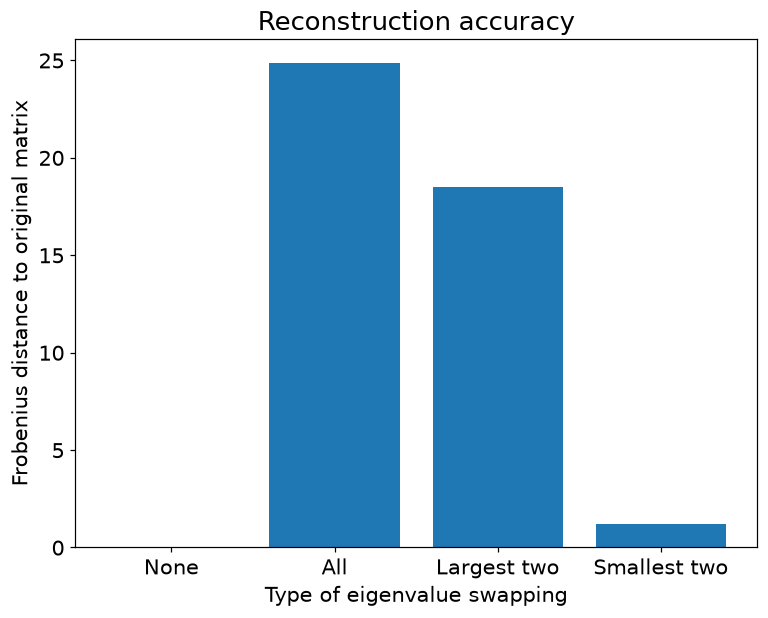

In [24]:
# now for the plot

plt.figure(figsize=(8,6))

plt.bar(range(4),reconAcc)
plt.xticks(range(4),labels=['None','All','Largest two','Smallest two'])
plt.ylabel('Frobenius distance to original matrix')
plt.xlabel('Type of eigenvalue swapping')
plt.title('Reconstruction accuracy')

plt.savefig(ASSET / 'Figure_12_03.png',dpi=140)
plt.show()

## 연습문제 4 · 난수행렬의 복소 고윳값

- **목표**: 일반 실수행렬에서도 복소 고윳값이 생김을 시각화합니다.
- **풀이 순서**: 42×42 난수행렬 123개의 고윳값을 √42로 나누고 실수부·허수부 평면에 그립니다.
- **결과 해석**: 켤레쌍으로 나타납니다. 원형 분포 경향을 보이는 유한 표본 실험이며 대칭행렬의 실수 고윳값 성질과 구분합니다.

### 코드 12-24

- 원본: `original_py/LA4DS_ch12.py` 372–392행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

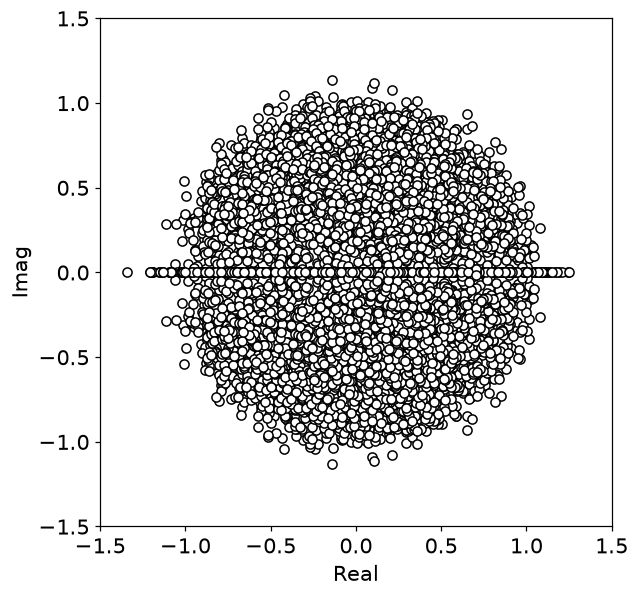

In [25]:
nIter = 123
matsize = 42
evals = np.zeros((nIter,matsize),dtype=complex)

# create the matrices and get their scaled eigenvalues
for i in range(nIter):
  A = np.random.randn(matsize,matsize)
  evals[i,:] = np.linalg.eig(A)[0] / np.sqrt(matsize)



# and show in a plot
plt.figure(figsize=(6,6))

plt.plot(np.real(evals),np.imag(evals),'ko',markerfacecolor='white')
plt.xlim([-1.5,1.5])
plt.ylim([-1.5,1.5])
plt.xlabel('Real')
plt.ylabel('Imag')
plt.savefig(ASSET / 'Figure_12_04.png',dpi=140)
plt.show()

## 연습문제 5 · 고유벡터와 이동행렬의 영공간

- **목표**: $(A-\lambda I)v=0$의 의미를 확인합니다.
- **풀이 순서**: 각 고윳값으로 A를 이동하고 영공간을 구해 대응하는 고유벡터 열과 비교합니다.
- **결과 해석**: 같은 1차원 공간이면 부호를 제외하고 일치합니다. 원본의 행 인덱싱을 고치고 허용오차를 명시했습니다. 비교에는 절대 코사인과 잔차도 유용합니다.

### 코드 12-25

- 원본: `original_py/LA4DS_ch12.py` 396–418행.
- **보완**: 고유벡터는 열에 저장되므로 영공간 비교 인덱스를 수정했습니다.
- **보완**: 고윳값의 부동소수점 오차를 고려하여 영공간 허용오차를 명시했습니다.

In [26]:
# get the null_space function from scipy
from scipy.linalg import null_space


# Create a symmetric matrix
N = 3
A = np.random.randn(N,N)
A = A@A.T

# eigendecompose
evals,evecs = np.linalg.eig(A)

# compare the eigenvectors with N(A-lI)
for i in range(N):

  # get the null space vector of the shifted matrix
  nullV = null_space( A-evals[i]*np.eye(N), rcond=1e-10 )

  # check for a match with the eigenvector via correlation (normalizes for magnitudes)
  r = np.corrcoef(nullV.T,evecs[:,i].reshape(1,-1))[0,1]

  # and print (abs(r))
  print(f'Correlation between N(A-lI) and evec {i}: {np.abs(r):.2f}')

Correlation between N(A-lI) and evec 0: 1.00
Correlation between N(A-lI) and evec 1: 1.00
Correlation between N(A-lI) and evec 2: 1.00


## 연습문제 6 · 원하는 고윳값으로 대칭행렬 생성

- **목표**: 분해식을 거꾸로 이용해 행렬을 설계합니다.
- **풀이 순서**: 양수 대각 Λ와 QR로 만든 Q를 사용해 $A=Q\Lambda Q^T$를 만듭니다. 대칭성과 스펙트럼을 확인합니다.
- **결과 해석**: A는 대칭이며 양의 고윳값이면 양의 정부호입니다. 난수 생성의 경계상 0이 있으면 준정부호가 됩니다.

### 코드 12-26

- 원본: `original_py/LA4DS_ch12.py` 422–432행.

In [27]:
# Create the Lambda matrix with positive values
Lambda = np.diag( np.random.rand(4)*5 )

# create Q
Q,_ = np.linalg.qr( np.random.randn(4,4) )

# reconstruct to a matrix
A = Q @ Lambda @ Q.T

# the matrix minus its transpose should be zeros (within precision error)
np.round( A-A.T ,5)

Out[27]: 
array([[ 0.,  0., -0., -0.],
       [-0.,  0., -0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0., -0.,  0.,  0.]])


### 코드 12-27

- 원본: `original_py/LA4DS_ch12.py` 434–436행.

In [28]:
# check eigenvalues against Lambda (sorting is helpful!)
print(np.sort(np.diag(Lambda)))
print(np.sort(np.linalg.eig(A)[0]))

[0.691145 1.606209 2.583673 2.969836]
[0.691145+0.j 1.606209+0.j 2.583673+0.j 2.969836+0.j]


## 연습문제 7 · 고윳값 평균으로 정규화 스케일 정하기

- **목표**: 11장 정규화의 스케일을 스펙트럼과 연결합니다.
- **풀이 순서**: 원본은 11장 연습 4를 참조만 합니다. 이 자료는 자전거 설계행렬을 다시 준비하는 독립 실행 셀을 추가해 평균 고윳값 기반 스케일을 계산합니다.
- **결과 해석**: $\operatorname{mean}\lambda(X^TX)=\|X\|_F^2/p$이므로 동일 gamma에서 기존 스케일의 1/p입니다. 강도 숫자만 같아도 같은 정규화가 아닙니다.

### 코드 12-28

- 원본: `original_py/LA4DS_ch12.py` 440–440행.
- **보완**: 원본에 없던 독립 실행·검증 코드를 추가했습니다.

Original 평균 고윳값: 907906.9366666666 Frobenius² / p: 907906.9366666666
Collinear 평균 고윳값: 852616.1993000002 Frobenius² / p: 852616.1992999997


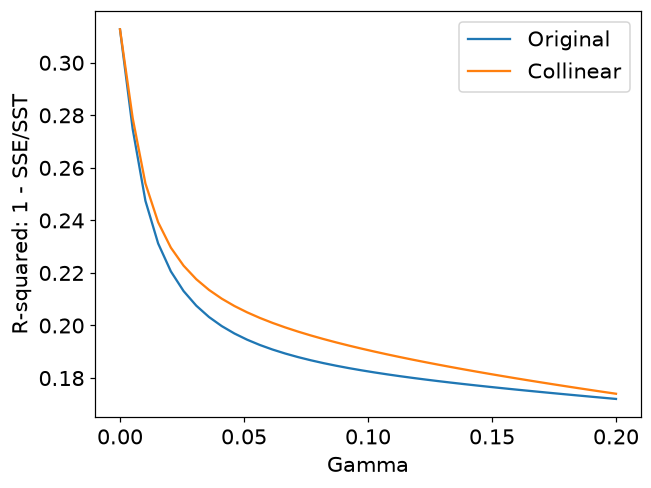

In [29]:
# Refer back to the code for Chapter 11, exercise 4.

# 추가 구현: 원본의 11장 연습 4 참조를 이 장에서 독립 실행
import pandas as pd
_bike = pd.read_csv(DATA / 'SeoulBikeData.csv', encoding='unicode_escape')
_X = np.column_stack([_bike['Rainfall(mm)'], _bike['Temperature(°C)'], np.ones(len(_bike))])
_Xm = np.column_stack([_X, 4*_X[:,0] + .4*_X[:,1]])
_y = _bike['Rented Bike Count'].to_numpy()
_gs = np.linspace(0,.2,40)
for _mat, _label in [(_X,'Original'), (_Xm,'Collinear')]:
    _scale = np.linalg.eigvalsh(_mat.T@_mat).mean()
    print(_label, '평균 고윳값:', _scale, 'Frobenius² / p:', np.linalg.norm(_mat,'fro')**2/_mat.shape[1])
    assert np.allclose(_scale,np.linalg.norm(_mat,'fro')**2/_mat.shape[1])
    _fits=[]
    for _g in _gs:
        _b = np.linalg.pinv(_mat.T@_mat+_g*_scale*np.eye(_mat.shape[1]))@_mat.T@_y
        _fits.append(1-np.sum((_y-_mat@_b)**2)/np.sum((_y-_y.mean())**2))
    plt.plot(_gs,_fits,label=_label)
plt.xlabel('Gamma'); plt.ylabel('R-squared: 1 - SSE/SST')
plt.legend(); plt.show()


## 연습문제 8 · 목표 상관을 가진 난수 생성

- **목표**: 공분산의 제곱근으로 독립 난수를 변환합니다.
- **풀이 순서**: 목표 R을 고유분해하고 $X=V\Lambda^{1/2}Z$로 표본을 생성해 표본 상관을 계산합니다.
- **결과 해석**: 표본 수가 유한하므로 R과 근사적으로 일치합니다. R이 양의 준정부호인지 확인해야 실수 제곱근을 사용할 수 있습니다.

### 코드 12-29

- 원본: `original_py/LA4DS_ch12.py` 444–456행.

In [30]:
# correlation matrix
R = np.array([[ 1,.2,.9],
              [.2, 1,.3],
              [.9,.3, 1] ])

# eigendecomposition
d,V = np.linalg.eig(R)
D = np.diag(d)

# create new data with imposed correlation
X = V @ np.sqrt(D) @ np.random.randn(3,10000)

np.corrcoef(X)

Out[30]: 
array([[1.      +0.j, 0.177602+0.j, 0.901008+0.j],
       [0.177602+0.j, 1.      +0.j, 0.283238+0.j],
       [0.901008+0.j, 0.283238+0.j, 1.      +0.j]])


## 연습문제 9 · 백색화

- **목표**: 상관된 데이터의 주방향 분산을 1로 맞춥니다.
- **풀이 순서**: 앞에서 만든 X를 고유기저로 회전하고 Λ의 제곱근 역수로 나눕니다. 변환 후 상관을 확인합니다.
- **결과 해석**: 대각은 1, 비대각은 0 근처입니다. 모집단 공분산으로 생성·변환한 유한 표본이라 정확히 항등행렬이 아닐 수 있습니다.

### 코드 12-30

- 원본: `original_py/LA4DS_ch12.py` 460–464행.

In [31]:
# now whiten
Y = X.T @ V @ np.linalg.inv(np.sqrt(D))

# and check the correlations
np.round( np.corrcoef(Y.T) ,3)

Out[31]: 
array([[ 1.   +0.j,  0.008+0.j, -0.012+0.j],
       [ 0.008+0.j,  1.   +0.j, -0.01 +0.j],
       [-0.012+0.j, -0.01 +0.j,  1.   +0.j]])


## 연습문제 10 · 일반화 고유벡터 정규화

- **목표**: 보통 내적과 B가중 내적을 구별합니다.
- **풀이 순서**: 대칭 양의 정부호 A,B로 eigh(A,B)를 실행하고 VtV와 VtBV를 그립니다.
- **결과 해석**: VtBV가 항등행렬입니다. B가 공간의 길이 척도를 정의한다고 보면 이해하기 쉽습니다.

### 코드 12-31

- 원본: `original_py/LA4DS_ch12.py` 468–492행.
- **보완**: 블로그용 그림 해상도를 140 dpi로 설정했습니다.

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:22: SyntaxWarning: invalid escape sequence '\m'
<ipython-input-32-2bf6ca9dfa77>:19: SyntaxWarning: invalid escape sequence '\m'
  axs[0].set_title('$\mathbf{V}^T\mathbf{V}$')
<ipython-input-32-2bf6ca9dfa77>:22: SyntaxWarning: invalid escape sequence '\m'
  axs[1].set_title('$\mathbf{V}^T\mathbf{B}\mathbf{V}$')


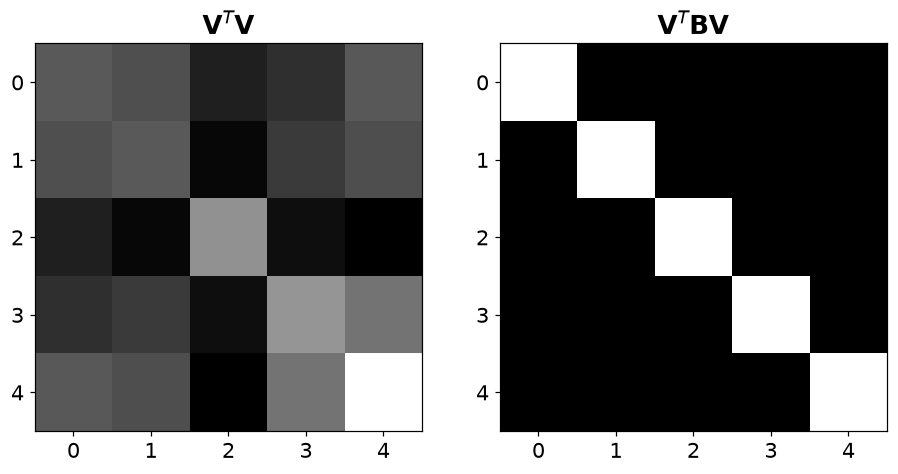

In [32]:
# two symmetric matrices and GED
n = 5
A = np.random.randn(n,n)
A = A.T@A
B = np.random.randn(n,n)
B = B.T@B

evals,evecs = eigh( A,B )

# eigenvectors times their transposes
VV  = evecs.T @ evecs
VBV = evecs.T @ B @ evecs


# show in an image
_,axs = plt.subplots(1,2,figsize=(10,6))

axs[0].imshow(VV,cmap='gray')
axs[0].set_title('$\mathbf{V}^T\mathbf{V}$')

axs[1].imshow(VBV,cmap='gray')
axs[1].set_title('$\mathbf{V}^T\mathbf{B}\mathbf{V}$')

plt.savefig(ASSET / 'Figure_12_05.png',dpi=140)
plt.show()

## 연습문제 11 · 고유벡터 스케일 변경

- **목표**: 역행렬 재구성과 전치 재구성의 차이를 확인합니다.
- **풀이 순서**: V에 π를 곱하고 VΛinv(V)로 복원합니다. 대칭행렬에서는 같은 스케일 변경 후 VΛVt도 시도합니다.
- **결과 해석**: inv(V)는 스케일을 상쇄하지만 Vt는 상쇄하지 않아 π² 배율이 남습니다. 전치를 역행렬처럼 쓰려면 열이 직교정규여야 합니다.

### 코드 12-32

- 원본: `original_py/LA4DS_ch12.py` 496–518행.
- **보완**: 각 고유벡터의 노름을 출력하도록 루프 인덱스를 수정했습니다.

In [33]:
# create the matrix
A = np.random.randint(-14,15,(4,4))


# diagonalize
d,V = np.linalg.eig(A)
V   = V*np.pi
D   = np.diag(d)
Vi  = np.linalg.inv(V)


# test for accurate reconstruction
print('Reconstructed minus original:')
print( np.round(V@D@Vi - A,3) )
print(' ')

# norms of the eigenvectors
for i in range(A.shape[0]):
  norm = np.sqrt(np.sum(V[:,i]*np.conj(V[:,i])))
  print(f'Eigenvector {i} has norm {norm}')


# Discussion: Scaling V doesn't matter because that scalar is normalized out in the matrix inverse.

Reconstructed minus original:
[[-0.-0.j  0.-0.j -0.-0.j  0.+0.j]
 [ 0.-0.j -0.+0.j  0.-0.j  0.+0.j]
 [-0.+0.j  0.+0.j -0.+0.j -0.+0.j]
 [ 0.-0.j -0.-0.j  0.-0.j  0.-0.j]]
 
Eigenvector 0 has norm (3.1415926535897927+0j)
Eigenvector 1 has norm (3.1415926535897936+0j)
Eigenvector 2 has norm (3.141592653589793+3.491703215800271e-18j)
Eigenvector 3 has norm (3.141592653589793-3.491703215800271e-18j)


### 코드 12-33

- 원본: `original_py/LA4DS_ch12.py` 520–544행.
- **보완**: 각 고유벡터의 노름을 출력하도록 루프 인덱스를 수정했습니다.

In [34]:
## repeat for a symmetric matrix using V' instead of inv(V)
# create the matrix
A = np.random.randint(-14,15,(4,4))
A = A.T@A


# diagonalize
d,V = np.linalg.eig(A)
V = V*np.pi
D = np.diag(d)
Vi = V.T


# test for accurate reconstruction
print('Reconstructed minus original:')
print( np.round(V@D@Vi - A,3) )
print(' ')

# norms of the eigenvectors
for i in range(A.shape[0]):
  norm = np.sqrt(np.sum(V[:,i]*np.conj(V[:,i])))
  print(f'Eigenvector {i} has norm {norm}')


# Discussion: Scaling V *does* matter because V is not explicitly inverted!

Reconstructed minus original:
[[1161.918+0.j  -70.957+0.j -966.787+0.j -115.305+0.j]
 [ -70.957+0.j 1942.443+0.j  283.827+0.j -576.524+0.j]
 [-966.787+0.j  283.827+0.j 2634.273+0.j 1977.922+0.j]
 [-115.305+0.j -576.524+0.j 1977.922+0.j 2536.707+0.j]]
 
Eigenvector 0 has norm (3.1415926535897936+0j)
Eigenvector 1 has norm (3.1415926535897936+0j)
Eigenvector 2 has norm (3.1415926535897927+0j)
Eigenvector 3 has norm (3.1415926535897936+0j)


### 코드 12-34

- 원본: `original_py/LA4DS_ch12.py` 546–546행.

In [35]:
# 

## 핵심 결과 다시 확인하기

- 아래는 원본과 별도로 추가한 작은 검증 예제입니다.
- `assert`가 통과하면 해당 수학적 관계가 지정한 수치 허용오차 안에서 성립한 것입니다.
- 큰 예제의 숫자를 외우기보다 이 관계가 왜 성립하는지 설명해 보세요.

In [36]:
_A=np.array([[2.,1.],[1.,2.]])
_lam,_V=np.linalg.eigh(_A)
print('고윳값:',_lam)
print('고유방정식 잔차:',np.linalg.norm(_A@_V-_V@np.diag(_lam)))
assert np.allclose(_lam,[1,3]) and np.allclose(_A,_V@np.diag(_lam)@_V.T)
assert np.allclose(_V.T@_V,np.eye(2))


고윳값: [1. 3.]
고유방정식 잔차: 0.0
